In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

file_path = r"\Users\aless\OneDrive\Desktop\MacrofinanceProject\quarterly_tfp.xlsx"
#first line contain a note about methodology
tfp_data = pd.read_excel(file_path,sheet_name='quarterly', skiprows=1) 
tfp_data = tfp_data[tfp_data['date'].astype(str).str.contains(r'\d{4}:Q\d', na=False)]
tfp_data['dtfp'] = pd.to_numeric(tfp_data['dtfp'], errors='coerce')
tfp_data['g'] = tfp_data['dtfp'] / 400.0 #from annualized dataset to quarterly log data
tfp_data_clean = tfp_data.dropna(subset=['g'])
g_series = tfp_data_clean['g'].values

# Model TFP growth as an AR(1)
y = g_series[1:]
X = sm.add_constant(g_series[:-1])
model = sm.OLS(y, X).fit()
a = model.params[0] #long run component
rho = model.params[1] # cycle persistence
sigma_eps = np.sqrt(model.mse_resid) #exogenous shock
print(f"Data Summary")
print(f"Sample period: {tfp_data_clean['date'].iloc[0]} to {tfp_data_clean['date'].iloc[-1]}")
print(f"Observations:  {len(g_series)}\n")
print("AR(1) Estimates")
print(f"Intercept (a):   {a:.6f}")
print(f"Persistence (p): {rho:.6f}")
print(f"Volatility (σε): {sigma_eps:.6f}\n")

Data Summary
Sample period: 1947:Q2 to 2026:Q1
Observations:  316

AR(1) Estimates
Intercept (a):   0.002590
Persistence (p): 0.144172
Volatility (σε): 0.008882



In [8]:
def rouwenhorst(N, rho, sigma_eps, a=0):
    """"
    Rouwenhorst discretization.
    Translates continuous macroeconomic shocks into a discrete 9-state Markov chain.
    Validate approximation confirming discrete grid's statistical moments match original continuous data.
    """
    sigma_z = sigma_eps / np.sqrt(1 - rho**2)
    psi = np.sqrt(N - 1) * sigma_z
    z_grid = np.linspace(-psi, psi, N)
    
    p = (1 + rho) / 2
    q = p
    P = np.array([[p, 1 - p], 
                  [1 - q, q]])
    # for N > 2
    for n in range(3, N + 1):
        P_new = np.zeros((n, n))
        P_new[:n-1, :n-1] += p * P
        P_new[:n-1, 1:n] += (1 - p) * P
        P_new[1:n, :n-1] += (1 - q) * P
        P_new[1:n, 1:n] += q * P
        P_new[1:n-1, :] /= 2
        P = P_new
    unconditional_mean = a / (1 - rho)
    z_grid += unconditional_mean
    return z_grid, P

states = 9
z_grid, P_matrix = rouwenhorst(states, rho, sigma_eps, a)
print(f"--- Rouwenhorst Discretization (N={states}) ---")
print("State Grid (z):")
print(np.round(z_grid, 6))
print("\nTransition Matrix (P):")
print(np.round(P_matrix, 4))

#Continuous vs. Discrete
stationary_dist = np.linalg.matrix_power(P_matrix, 1000)[0]
mean_disc = np.sum(z_grid * stationary_dist)
var_disc = np.sum((z_grid - mean_disc)**2 * stationary_dist)
continuous_mean = a / (1 - rho)
continuous_var = sigma_eps**2 / (1 - rho**2)
print("\n--- Moment Comparison check ---")
print(f"Continuous Mean: {continuous_mean:.8f} | Discretized Mean: {mean_disc:.8f}")
print(f"Continuous Var:  {continuous_var:.8f} | Discretized Var:  {var_disc:.8f}")


--- Rouwenhorst Discretization (N=9) ---
State Grid (z):
[-0.022361 -0.016014 -0.009667 -0.00332   0.003027  0.009374  0.015721
  0.022068  0.028414]

Transition Matrix (P):
[[0.0115 0.0687 0.1797 0.2689 0.2514 0.1504 0.0563 0.012  0.0011]
 [0.0086 0.0564 0.1609 0.2605 0.2621 0.1679 0.0669 0.0152 0.0015]
 [0.0064 0.046  0.1424 0.2493 0.2701 0.1856 0.0791 0.0191 0.002 ]
 [0.0048 0.0372 0.1246 0.2356 0.2751 0.2032 0.0928 0.024  0.0027]
 [0.0036 0.03   0.108  0.22   0.2767 0.22   0.108  0.03   0.0036]
 [0.0027 0.024  0.0928 0.2032 0.2751 0.2356 0.1246 0.0372 0.0048]
 [0.002  0.0191 0.0791 0.1856 0.2701 0.2493 0.1424 0.046  0.0064]
 [0.0015 0.0152 0.0669 0.1679 0.2621 0.2605 0.1609 0.0564 0.0086]
 [0.0011 0.012  0.0563 0.1504 0.2514 0.2689 0.1797 0.0687 0.0115]]

--- Moment Comparison check ---
Continuous Mean: 0.00302685 | Discretized Mean: 0.00302685
Continuous Var:  0.00008057 | Discretized Var:  0.00008057


In [9]:
alpha = 0.33 
beta = 0.99 
delta = 0.025 
Z = np.exp(z_grid)
N_z = len(z_grid)
P = P_matrix
n_k = 500
k_ss = (alpha / (1/beta - (1 - delta))) ** (1 / (1 - alpha))
k_min, k_max = 0.5 * k_ss, 1.5 * k_ss
k_grid = np.linspace(k_min, k_max, n_k)
gamma_values = [0.5, 1.5, 3.0, 5.0, 10.0]
policy_results = {}
for gamma in gamma_values:
    print(f"comp. for gamma={gamma}")
    K_mesh, Z_mesh, K_prime_mesh = np.meshgrid(k_grid, Z, k_grid, indexing='ij')
    C = Z_mesh * (K_mesh ** alpha) + (1 - delta) * K_mesh - K_prime_mesh
    U = np.full(C.shape, -1e10)
    feasible = C > 0
    U[feasible] = (C[feasible] ** (1 - gamma) - 1) / (1 - gamma)
    V = np.zeros((n_k, N_z))
    V_new = np.zeros_like(V)
    policy_k_idx = np.zeros((n_k, N_z), dtype=int)
    tolerance = 1e-6
    max_iter = 1500
    for it in range(max_iter):
        EV = V @ P.T  
        EV_expanded = EV.T[np.newaxis, :, :] 
        RHS = U + beta * EV_expanded
        V_new = np.max(RHS, axis=2)
        policy_k_idx = np.argmax(RHS, axis=2)
        if np.max(np.abs(V_new - V)) < tolerance:
            print(f"Convergence achieved at iteration {it}")
            V = V_new
            break  
        V = V_new.copy() 
    k_prime_policy = k_grid[policy_k_idx]
    K_grid_2D, Z_grid_2D = np.meshgrid(k_grid, Z, indexing='ij')
    c_policy = Z_grid_2D * (K_grid_2D ** alpha) + (1 - delta) * K_grid_2D - k_prime_policy
    policy_results[gamma] = {
        'k_prime': k_prime_policy.copy(),
        'c': c_policy.copy()
    }

comp. for 0.5
Convergence achieved at iteration 1371
comp. for 1.5
Convergence achieved at iteration 1332
comp. for 3.0
Convergence achieved at iteration 1283
comp. for 5.0
Convergence achieved at iteration 1233
comp. for 10.0
Convergence achieved at iteration 1156


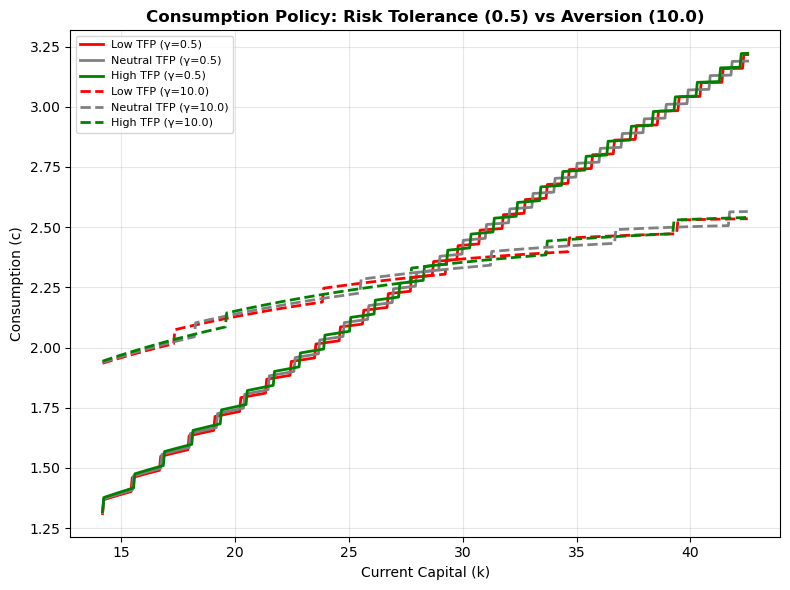

In [10]:
gammas_plot = [0.5, 10.0]
line_styles = ['-', '--'] 
z_indices = [0, N_z // 2, N_z - 1]
labels = ['Low TFP', 'Neutral TFP', 'High TFP']
colors = ['red', 'grey', 'green']
fig, ax = plt.subplots(figsize=(8, 6))
for gamma, ls in zip(gammas_plot, line_styles):
    for z_idx, label, color in zip(z_indices, labels, colors):
        leg_label = f"{label} (\u03B3={gamma})"
        # Plotting consumption policy function
        ax.plot(k_grid, policy_results[gamma]['c'][:, z_idx], 
                label=leg_label, color=color, linestyle=ls, linewidth=2)

ax.set_title("Consumption Policy: Risk Tolerance (0.5) vs Aversion (10.0)", fontsize=12, fontweight='bold')
ax.set_xlabel("Current Capital (k)", fontsize=10)
ax.set_ylabel("Consumption (c)", fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
np.random.seed(323)
T = 11000
burn_in = 1000
N_sim = T - burn_in
N_z = len(z_grid)
current_z_idx = N_z // 2
z_sim_indices = np.zeros(T, dtype=int)
z_sim_indices[0] = current_z_idx
for t in range(1, T):
    probs = P_matrix[z_sim_indices[t-1], :]
    z_sim_indices[t] = np.random.choice(N_z, p=probs)
final_table_data = []
for gamma in gamma_values:
    c_policy = policy_results[gamma]['c']
    k_prime_policy = policy_results[gamma]['k_prime'] 
    k_sim = np.zeros(T)
    c_sim = np.zeros(T)
    rf_sim = np.zeros(T) # Gross quarterly risk-free rate
    re_sim = np.zeros(T) # Gross quarterly equity return
    k_sim[0] = k_grid[len(k_grid)//2] # Start at middle of grid
    for t in range(T-1):
        z_idx = z_sim_indices[t]
        k_t = k_sim[t]
        c_t = np.interp(k_t, k_grid, c_policy[:, z_idx])
        k_next = np.interp(k_t, k_grid, k_prime_policy[:, z_idx])
        k_sim[t+1] = k_next
        c_sim[t] = c_t
        expected_m = 0
        for z_next_idx in range(N_z):
            prob = P_matrix[z_idx, z_next_idx]
            c_next = np.interp(k_next, k_grid, c_policy[:, z_next_idx])
            m_next = beta * (c_next / c_t)**(-gamma)
            expected_m += prob * m_next
        rf_sim[t] = 1.0 / expected_m if expected_m > 0 else np.nan
        # Calculate realized Equity Return R^e_{t+1} (Gross Quarterly)
        z_next_realized_idx = z_sim_indices[t+1]
        z_next_val = z_grid[z_next_realized_idx]
        re_next = alpha * np.exp(z_next_val) * (k_next ** (alpha - 1)) + (1 - delta)
        re_sim[t] = re_next
    c_path = c_sim[burn_in:-1]
    rf_path = rf_sim[burn_in:-1]
    re_path = re_sim[burn_in:-1]
    c_growth = np.log(c_path[1:] / c_path[:-1])
    mean_dlogc = np.mean(c_growth)
    std_dlogc = np.std(c_growth)
    corr_dlogc = pd.Series(c_growth).autocorr(lag=1)
    mean_rf_gross_q = np.mean(rf_path)
    mean_re_gross_q = np.mean(re_path)
    ann_rf_net = (mean_rf_gross_q ** 4) - 1
    ann_re_net = (mean_re_gross_q ** 4) - 1
    ann_equity_premium = ann_re_net - ann_rf_net
    
    #formatting result as percentages for readability
    final_table_data.append({
        'Gamma': gamma,
        'E[R^f] (%)': ann_rf_net * 100,
        'E[R^e] (%)': ann_re_net * 100,
        'E[R^e - R^f] (%)': ann_equity_premium * 100,
        'E[dlog c]': mean_dlogc,
        'std(dlog c)': std_dlogc,
        'Corr(t, t-1)': corr_dlogc
    })
    
df_results = pd.DataFrame(final_table_data)
print("\n" + "="*85)
print("PART (h): QUANTITATIVE RESULTS TABLE")
print("="*85)
print(df_results.to_string(index=False))
print("="*85)


PART (h): QUANTITATIVE RESULTS TABLE
 Gamma  E[R^f] (%)  E[R^e] (%)  E[R^e - R^f] (%)     E[dlog c]  std(dlog c)  Corr(t, t-1)
   0.5    4.095846    4.109677          0.013832 -8.297318e-07     0.010176     -0.487978
   1.5    4.053457    4.108660          0.055202 -8.545579e-07     0.010030     -0.488574
   3.0    4.054569    4.120746          0.066177 -9.545497e-07     0.009873     -0.490663
   5.0    4.085733    4.124154          0.038420 -1.054551e-06     0.009827     -0.494463
  10.0    4.147706    4.143668         -0.004038 -1.254615e-06     0.009741     -0.495136
